In [39]:
import numpy as np
import matplotlib.pyplot as plt

#### for Poisson Distribution

Initial Sample Mean (λ) = 8.36


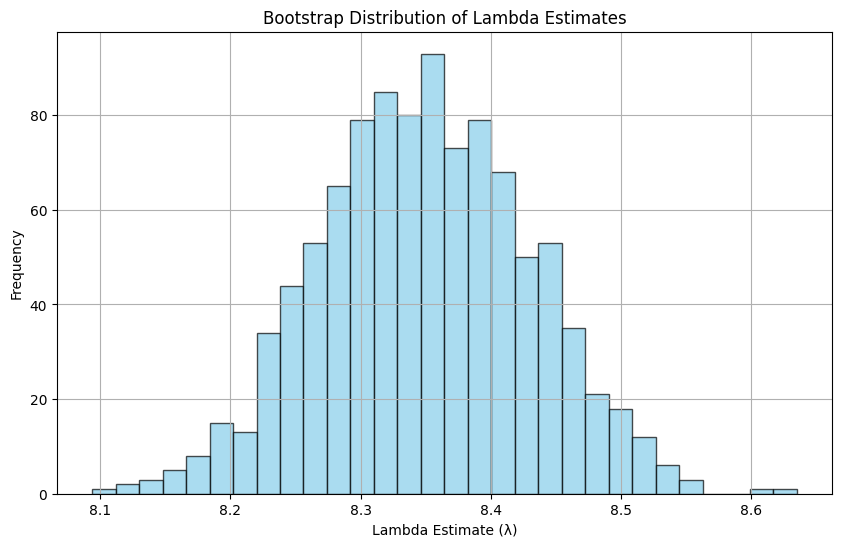

Bootstrap Mean of Lambda Estimates = 8.3495
Bootstrap Std Dev of Lambda Estimates = 0.0810


In [40]:
from scipy.stats import poisson

#data
n = np.arange(18) # no of counts per 10-second interval
ObservedCounts = [1,6,11,28,56,105,126,146,164,161,123,101,74,53,23,15,9,5]

sample_mean = np.average(n, weights=ObservedCounts) #initial estimate of lambda (rate parameter) using sample mean
print(f"Initial Sample Mean (λ) = {sample_mean:.2f}")
# number of bootstrap samples
num_bootstrap = 1000
bootstrap_lambdas = []

# bootstrap procedure
for _ in range(num_bootstrap):
    #generate synthetic dataset using estimated lambda
    synthetic_data = np.random.poisson(lam=sample_mean, size=sum(ObservedCounts)) # generate synthetic data with same total count as observed

    # bin the synthetic data to match observed counts format
    synthetic_hist, _ = np.histogram(synthetic_data, bins=np.arange(19))

    # calculate the new lambda estimate from the synthetic dataset  
    new_lambda = np.average(n, weights=synthetic_hist)

    #store the new lambda estimate
    bootstrap_lambdas.append(new_lambda)

# plot distribution of bootstrap lambda estimates
plt.figure(figsize=(10,6))
plt.hist(bootstrap_lambdas, bins=30, color='skyblue', edgecolor='black',alpha=0.7)
plt.title('Bootstrap Distribution of Lambda Estimates')
plt.xlabel('Lambda Estimate (λ)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print(f"Bootstrap Mean of Lambda Estimates = {np.mean(bootstrap_lambdas):.4f}")
print(f"Bootstrap Std Dev of Lambda Estimates = {np.std(bootstrap_lambdas):.4f}")

Observed Standard Deviation = 2.94


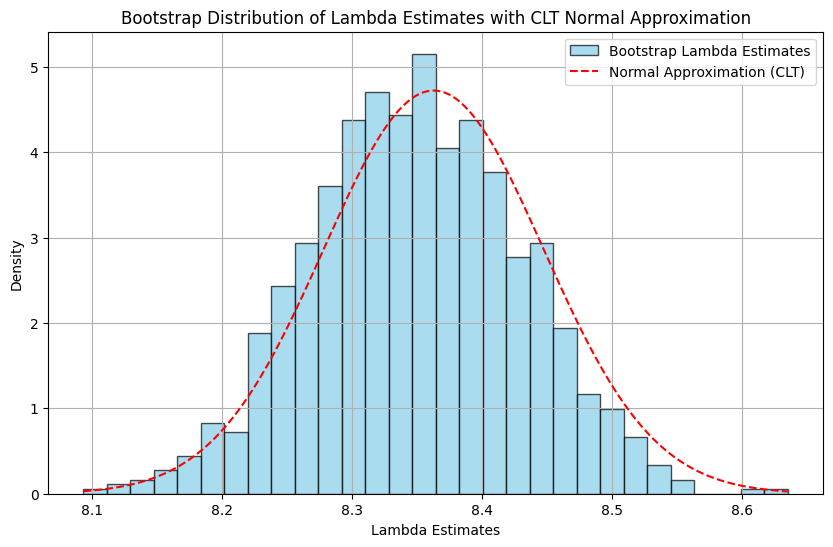

In [41]:
from scipy.stats import norm

# calculate the sample stadard deviation of the observed data
observed_std = np.sqrt(np.average((n - sample_mean)**2, weights=ObservedCounts))
print(f"Observed Standard Deviation = {observed_std:.2f}")

# calculate central limit theoram (CLT) - based standard deviation for lambda estimates
clt_std = observed_std / np.sqrt(sum(ObservedCounts))

# geerate the normal distribution of lambda estimates based on CLT approximation
x = np.linspace(min(bootstrap_lambdas), max(bootstrap_lambdas), 1000)
normal_approximation = norm.pdf(x, loc=sample_mean, scale=clt_std) 

# plot normal distribution approximation on the top of the bootstrap distribution histogram
plt.figure(figsize=(10,6))
plt.hist(bootstrap_lambdas, bins=30, color='skyblue', edgecolor='black', alpha=0.7, density=True, label='Bootstrap Lambda Estimates')
plt.plot(x, normal_approximation, color='red', linestyle='--', label='Normal Approximation (CLT)')
plt.title('Bootstrap Distribution of Lambda Estimates with CLT Normal Approximation')
plt.xlabel('Lambda Estimates')
plt.ylabel('Density')
plt.grid(True)
plt.legend()
plt.show()


#### for Normal Distribution 

Estimated Mean (μ) = 9.72
Estimated Variance (σ^2) = 4.52


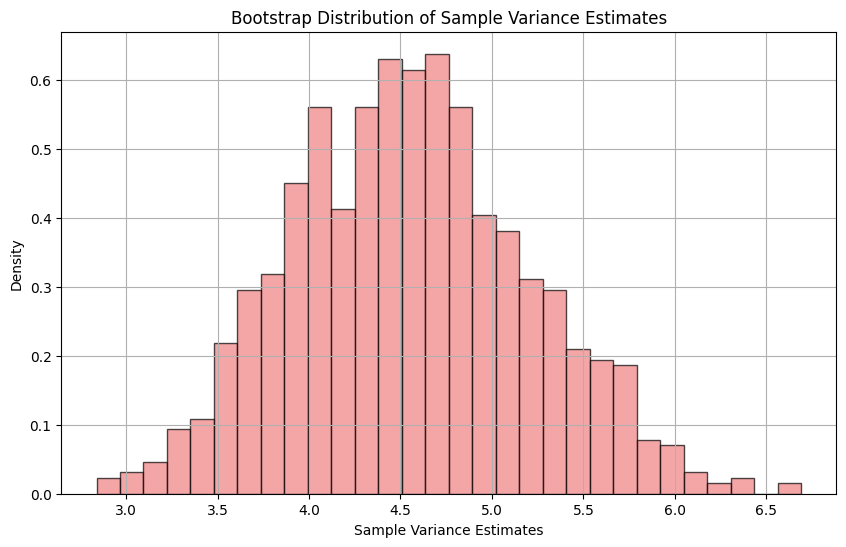

Bootstrap Mean of Sample Variance Estimates = 4.5520
Bootstrap Std Dev of Sample Variance Estimates = 0.6511
method of moments Estimated Variance = 4.5241


In [44]:
np.random.seed(41) # for reproducibility

# generate data from normal distribution 
mu = 10
sigama = 2
N = 100
data = np.random.normal(loc=mu, scale=sigama, size=N)

# method of moments estimates for mean and variance
estimated_mu = np.mean(data)
estimated_var = np.var(data, ddof=1) 
print(f"Estimated Mean (μ) = {estimated_mu:.2f}")
print(f"Estimated Variance (σ^2) = {estimated_var:.2f}")

# number of synthetic datasets to generate (bootstrap samples)
num_synthetic_samples = 1000  
synthetic_vars = []

# generate synthetic datasets using the estimated mean and variance and calculate variance for each
for _ in range(num_synthetic_samples):
    # generate synthetic dataset from normal distribution with estimated parameters
    synthetic_data = np.random.normal(loc=estimated_mu, scale=np.sqrt(estimated_var), size=N)
    # calculate the variance of the synthetic dataset
    synthetic_var = np.var(synthetic_data, ddof=1) # unbiased variance estimate
    synthetic_vars.append(synthetic_var)

# plot the distribution of synthetic sample variances
plt.figure(figsize=(10,6))
plt.hist(synthetic_vars, bins=30, color='lightcoral', edgecolor='black', alpha=0.7, density=True)
plt.title('Bootstrap Distribution of Sample Variance Estimates')
plt.xlabel('Sample Variance Estimates')
plt.ylabel('Density')
plt.grid(True)
plt.show()

print(f"Bootstrap Mean of Sample Variance Estimates = {np.mean(synthetic_vars):.4f}")
print(f"Bootstrap Std Dev of Sample Variance Estimates = {np.std(synthetic_vars):.4f}")
print(f"method of moments Estimated Variance = {estimated_var:.4f}")

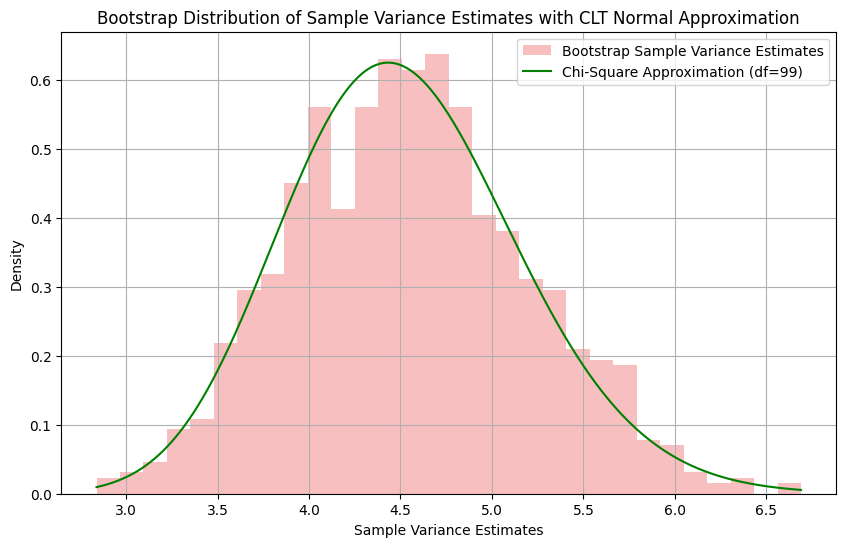

Bootstrap Mean of Sample Variance Estimates = 4.5520
Bootstrap Std Dev of Sample Variance Estimates = 0.6511
Method of Moments Estimated Variance = 4.5241


In [46]:
# # normal approximation for the distribution of sample variance estimates using CLT
# x = np.linspace(min(synthetic_vars), max(synthetic_vars), 1000)
# clt_variance = 2 * (estimated_var**2) / (N - 1)
# clt_sd = np.sqrt(clt_variance)

# normal_approximation = norm.pdf(
#     x,
#     loc=estimated_var,
#     scale=clt_sd
# )

# plot CLT-based normal distribution approximation on the top of the bootstrap distribution histogram
plt.figure(figsize=(10,6))
plt.hist(synthetic_vars, bins=30, color='lightcoral', alpha=0.5, density=True, label='Bootstrap Sample Variance Estimates')
# plt.plot(x, normal_approximation, color='blue', lw=2, label=f'Normal Approximation (CLT) \nMean={estimated_var:.4f}, Std Error={clt_std_error:.4f}')

#chi-square distribution approximation for sample variance estimates
from scipy.stats import chi2
df = N - 1  # degrees of freedom for sample variance
chi2_x = np.linspace(min(synthetic_vars), max(synthetic_vars), 1000)
chi2_pdf = chi2.pdf(df*chi2_x/estimated_var, df) * (df/estimated_var)  # scale the chi-square distribution to match the variance estimates
plt.plot(chi2_x, chi2_pdf, color='green', linestyle='-', label=f'Chi-Square Approximation (df={df})')

plt.title('Bootstrap Distribution of Sample Variance Estimates with CLT Normal Approximation')
plt.xlabel('Sample Variance Estimates')
plt.ylabel('Density')
plt.grid(True)
plt.legend()
plt.show()

# print summary of results
synthetic_mean_variance = np.mean(synthetic_vars)
synthetic_std_variance = np.std(synthetic_vars)
print(f"Bootstrap Mean of Sample Variance Estimates = {synthetic_mean_variance:.4f}")
print(f"Bootstrap Std Dev of Sample Variance Estimates = {synthetic_std_variance:.4f}")
print(f"Method of Moments Estimated Variance = {estimated_var:.4f}")